# MSA 2026 Phase 2 - Part 2: Maximum Temperature Prediction from Weather Data

## 1. Load and check the dataset

In [3]:
import pandas as pd

### Load dataset
weather_df = pd.read_csv("Summary of Weather.csv", low_memory=False)

### Check number of rows and columns in each dataset
print("Weather Dataset: ", weather_df.shape)
print(weather_df.columns)


### Display the first five instances.
print("First 5 instances:")
print(weather_df.head())


### Key statistical measures
numeric_variables = ["Precip", "WindGustSpd", "MaxTemp", "MinTemp",
       "MeanTemp", "Snowfall", "PoorWeather", "PRCP", "DR",
       "SPD", "MAX", "MIN", "MEA", "SNF", "SND", "FT", "FB", "FTI", "ITH",
       "PGT", "TSHDSBRSGF", "SD3", "RHX", "RHN", "RVG", "WTE"]
print(weather_df[numeric_variables].describe())

### Correlations between variables
correlation_weather_df = weather_df.corr(numeric_only=True)
print(correlation_weather_df)
max_temp_corr = correlation_weather_df["MaxTemp"]
print(max_temp_corr.sort_values(ascending=False))

### Convert types of variables into numerical values
## Check type of each variable and null values
# Number of non-null values of each variable and its types:
print(weather_df.info())

# Percentage of missing values in each column
print((weather_df.isnull().sum() / len(weather_df) *100).sort_values(ascending=False))

# Check variables which may be duplicates of each other.
duplicate_variables = ["Precip","PRCP", "MaxTemp", "MAX", "MinTemp", "MIN", "MeanTemp", "MEA", "Snowfall", "SNF"]
for var in duplicate_variables:
    print(weather_df[var].head(15))

## Check duplicated rows:
print("\nNumber of duplicate rows:", weather_df.duplicated().sum())

Weather Dataset:  (119040, 31)
Index(['STA', 'Date', 'Precip', 'WindGustSpd', 'MaxTemp', 'MinTemp',
       'MeanTemp', 'Snowfall', 'PoorWeather', 'YR', 'MO', 'DA', 'PRCP', 'DR',
       'SPD', 'MAX', 'MIN', 'MEA', 'SNF', 'SND', 'FT', 'FB', 'FTI', 'ITH',
       'PGT', 'TSHDSBRSGF', 'SD3', 'RHX', 'RHN', 'RVG', 'WTE'],
      dtype='str')
First 5 instances:
     STA      Date Precip  WindGustSpd    MaxTemp    MinTemp   MeanTemp  \
0  10001  1942-7-1  1.016          NaN  25.555556  22.222222  23.888889   
1  10001  1942-7-2      0          NaN  28.888889  21.666667  25.555556   
2  10001  1942-7-3   2.54          NaN  26.111111  22.222222  24.444444   
3  10001  1942-7-4   2.54          NaN  26.666667  22.222222  24.444444   
4  10001  1942-7-5      0          NaN  26.666667  21.666667  24.444444   

  Snowfall PoorWeather  YR  ...  FB  FTI ITH  PGT  TSHDSBRSGF  SD3  RHX  RHN  \
0        0         NaN  42  ... NaN  NaN NaN  NaN         NaN  NaN  NaN  NaN   
1        0         NaN  42  ... Na

## 2. Clean the dataset, drop variables

In [4]:
### Drop variables:
## Drop columns having >70% of missing values & columns which are duplicate?
adjusted_weather_df = weather_df.drop(columns=['SD3', 'RHN', 'RHX', 'RVG', 'FT', 'FTI', 'WTE', 
                         'ITH', 'FB', 'PGT', 'WindGustSpd', 'SPD', 'DR', 'SND', 'PoorWeather', 'TSHDSBRSGF',
                         'PRCP', 'SNF', 'MEA', 'MAX', 'MIN', 'YR', 'MO', 'DA'])

## Drop duplicate rows:
adjusted_weather_df = adjusted_weather_df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", adjusted_weather_df.shape)

### Clean dataset:
## Convert the Date column to datetime type
adjusted_weather_df["Date"] = pd.to_datetime(weather_df["Date"]) 

## Convert value "T" to 0.01 & invalid values to NaN
variables = ['Precip', 'Snowfall']
for var in variables:
    adjusted_weather_df[var] = adjusted_weather_df[var].replace("T", "0.01")
    adjusted_weather_df[var] = pd.to_numeric(adjusted_weather_df[var], errors='coerce')

## Check types of columns
print(adjusted_weather_df.info())

## Percentage of missing values in each column
print((adjusted_weather_df.isnull().sum() / len(weather_df) *100).sort_values(ascending=False))

## Drop rows contain NaN in Snowfall column:
adjusted_weather_df = adjusted_weather_df.dropna(axis=0, how='any')

# Check null values:
print("Null values:")
print(adjusted_weather_df.isnull().sum())

# Number of rows after dropping NaN values:
print("Number of rows:", adjusted_weather_df.shape[0])

Shape after dropping duplicates: (119030, 7)
<class 'pandas.DataFrame'>
RangeIndex: 119030 entries, 0 to 119029
Data columns (total 7 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   STA       119030 non-null  int64         
 1   Date      119030 non-null  datetime64[us]
 2   Precip    119030 non-null  float64       
 3   MaxTemp   119030 non-null  float64       
 4   MinTemp   119030 non-null  float64       
 5   MeanTemp  119030 non-null  float64       
 6   Snowfall  117823 non-null  float64       
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 6.4 MB
None
Snowfall    1.013945
Date        0.000000
STA         0.000000
Precip      0.000000
MaxTemp     0.000000
MinTemp     0.000000
MeanTemp    0.000000
dtype: float64
Null values:
STA         0
Date        0
Precip      0
MaxTemp     0
MinTemp     0
MeanTemp    0
Snowfall    0
dtype: int64
Number of rows: 117823


## 3. Select the feature(s) for the model, and explain the reason

In [11]:
# write your answer here
# Variables after cleaning that dataset:
print("Columns after cleaning that dataset")
print(adjusted_weather_df.columns)

Columns after cleaning that dataset
Index(['STA', 'Date', 'Precip', 'MaxTemp', 'MinTemp', 'MeanTemp', 'Snowfall'], dtype='str')


SELECT:
- MaxTemp: This variable is response variable used for training and validating models
- Precip: This variable records the precipitation of different days at the stations. Rainy days tend to have cooler weather which is very useful information to predict maximum temperature.
- MinTemp: This variable is an independent variable which is very important for maximum temperaure prediction. The variable is a signal for the model to predict because it shows the minimum level that the temperature of a day can reach which means the maximum temperature has to be higher. The strong association between MinTemp and MaxTemp is also shown by the correlation which is around 0.88.
- Snowfall: This variable records the amount of snow fall at the given stations. Snow is only occurs in cold weather which is very informative to predict the maximum temperature.

NOT SELECT:
- STA: This variable is the station ID for identifier which do not provide useful information related to its location or geographic features, such as climate zone, to predict the maximum temperature.
- Date: This variable is the date of the day that they record other variables which also do not provide useful information to predict the maximum temperature.
- MeanTemp: This variable is a dependent variable which calculated by using MinTemp and MaxTemp (variable that I target to predict). This is shown by the correlation between MeanTemp and MaxTemp (~0.97). The model can obviously know what the exact MaxTemp values should be when knowing MinTemp and MeanTemp. So including MeanTemp for train models can lead to data leakage. 
- MAX, MIN, and MEA: These three variables are MaxTemp, MinTemp, and MeanTemp which are converted into different measurements. For example, MAX is MaxTemp in Fahrenheit which means including MAX directly give the model the target variable that I am trying to predict. This leads to data leakage, not merely duplicated information.
- Other variables: They are not informative for MaxTemp prediction because:
    + PoorWeather, TSHDSBRSGF have more than 70% of the data missed in their columns
    + SD3, RHN, RHX, RVG, FT, FTI, WTE, ITH, FB, PGT, WindGustSpd, SPD, DR, SND have 95-100% of the data missed

## 4. Split the dataset (70% for training, 30% for testing)

In [6]:
from sklearn.model_selection import train_test_split

# Separate features (X) and labels (y)
x, y = adjusted_weather_df[['Precip', 'MinTemp', 'Snowfall']].values, adjusted_weather_df['MaxTemp'].values

# Split data 70%-30% into training set and test set
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=1)

print (f'Training Set: {x_train.shape[0]} rows\nTest Set: {x_test.shape[0]} rows')

Training Set: 82476 rows
Test Set: 35347 rows


## 5. Choose the algorithm, train and test the model

In [7]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
 
models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(),
    'Decision Tree': DecisionTreeRegressor(random_state=0),
    'Random Forest': RandomForestRegressor(random_state=0),
    'Gradient Boosting': GradientBoostingRegressor(random_state=0),
}

fitted_models = {}
for key, value in models.items():
    fitted_models[key] = value.fit(x_train, y_train)
    print(f"Model trained: {key}")

print(fitted_models)

Model trained: Linear Regression
Model trained: Lasso
Model trained: Decision Tree
Model trained: Random Forest
Model trained: Gradient Boosting
{'Linear Regression': LinearRegression(), 'Lasso': Lasso(), 'Decision Tree': DecisionTreeRegressor(random_state=0), 'Random Forest': RandomForestRegressor(random_state=0), 'Gradient Boosting': GradientBoostingRegressor(random_state=0)}


## 6. Evaluate and Visualize model Performance

               Model                                   Predicted Values  \
0  Gradient Boosting  [27.974408316704455, 31.864862404705143, 33.80...   
1      Random Forest  [27.945418989205105, 31.864680341669686, 33.87...   
2      Decision Tree  [28.000000000222226, 31.868765496196165, 33.89...   
3  Linear Regression  [28.787999567616804, 31.789278067448155, 34.75...   
4              Lasso  [28.7257493743591, 31.71871641997662, 34.68567...   

   Mean Error        MSE      RMSE        R2  
0   -0.014432  12.004385  3.464734  0.827860  
1   -0.008084  12.422426  3.524546  0.821865  
2   -0.004968  12.943989  3.597776  0.814386  
3   -0.002697  16.282665  4.035178  0.766510  
4   -0.003498  16.394552  4.049019  0.764906  


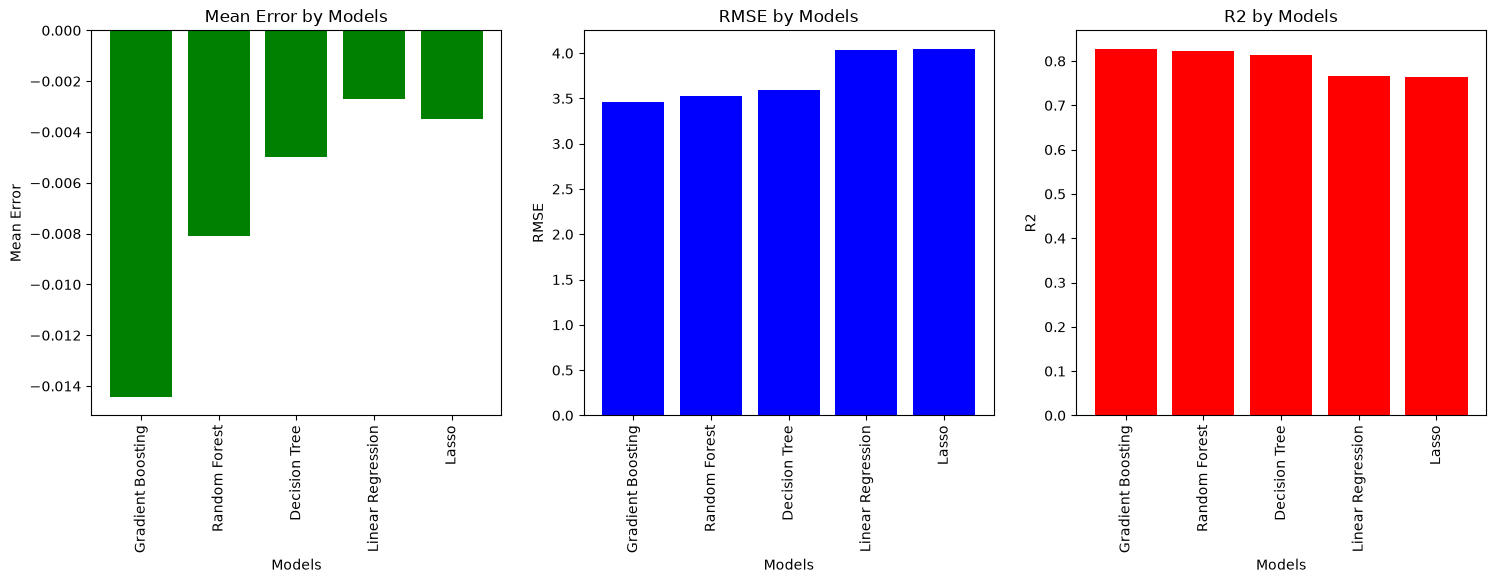

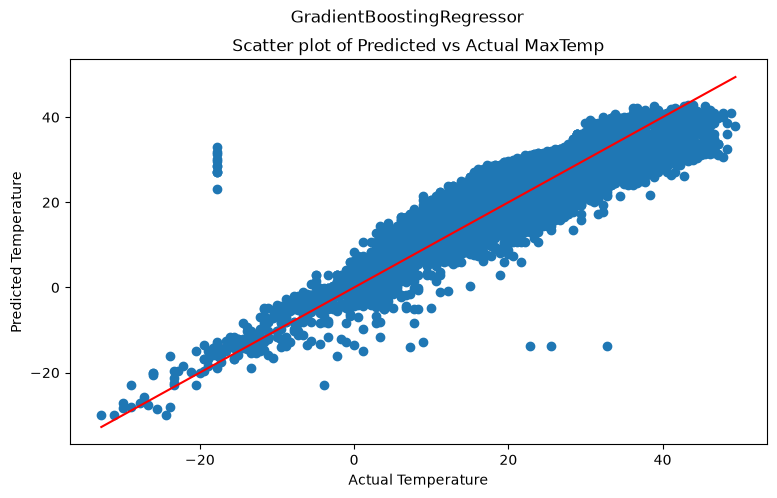

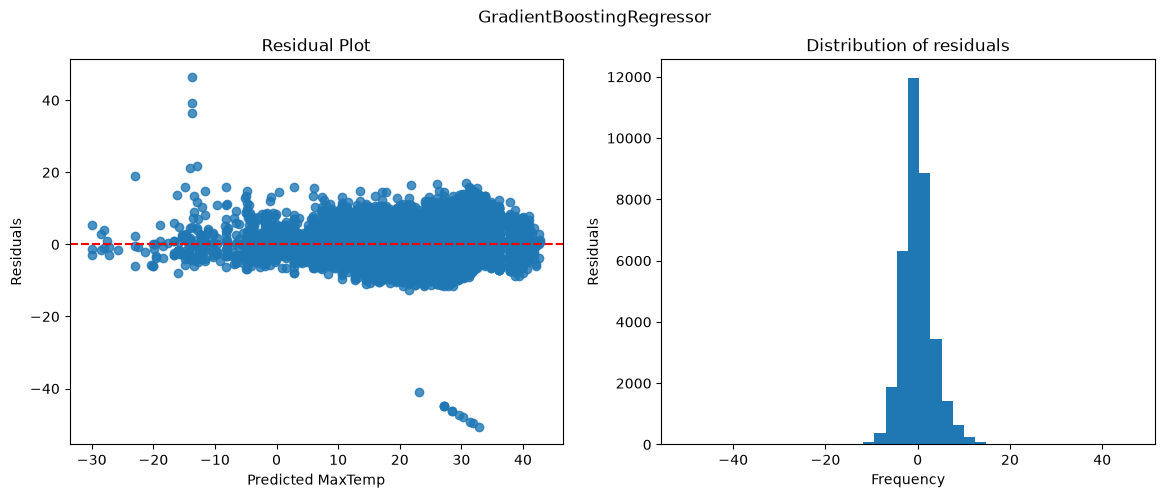

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

predictions = []
for key, prediction in fitted_models.items():
    pred_values  = prediction.predict(x_test)
    mean_errors = np.mean(y_test - pred_values)
    mse = mean_squared_error(y_test, pred_values)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred_values)
    predictions.append(
        {
            'Model': key,
            'Predicted Values' : pred_values,
            'Mean Error': mean_errors,
            'MSE' : mse,
            'RMSE' : rmse,
            'R2' : r2,
        }
    )


prediction_df = pd.DataFrame(predictions).sort_values('R2', ascending=False).reset_index(drop=True)
print(prediction_df)


### Visualisation:
## Measurements of models
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
# Mean Error
ax[0].bar(prediction_df['Model'], prediction_df['Mean Error'], color='green')
ax[0].set_title("Mean Error by Models")
ax[0].set_xlabel("Models")
ax[0].tick_params(axis='x', labelrotation=90)
ax[0].set_ylabel("Mean Error")

# RMSE
ax[1].bar(prediction_df['Model'], prediction_df['RMSE'], color='blue')
ax[1].set_title("RMSE by Models")
ax[1].set_xlabel("Models")
ax[1].tick_params(axis='x', labelrotation=90)
ax[1].set_ylabel("RMSE")

# R2
ax[2].bar(prediction_df['Model'], prediction_df['R2'], color='red')
ax[2].set_title("R2 by Models")
ax[2].set_xlabel("Models")
ax[2].tick_params(axis='x', labelrotation=90)
ax[2].set_ylabel("R2")
plt.show()

Choose GradientBoostingRegressor:
Based on the average of error between the predicted MaxTemp and actual MaxTemp, Gradient Boosting Model has the lowest value (0.005527) and is considered to be the most suitable model for the data set to predict MaxTemp out of 5 models.

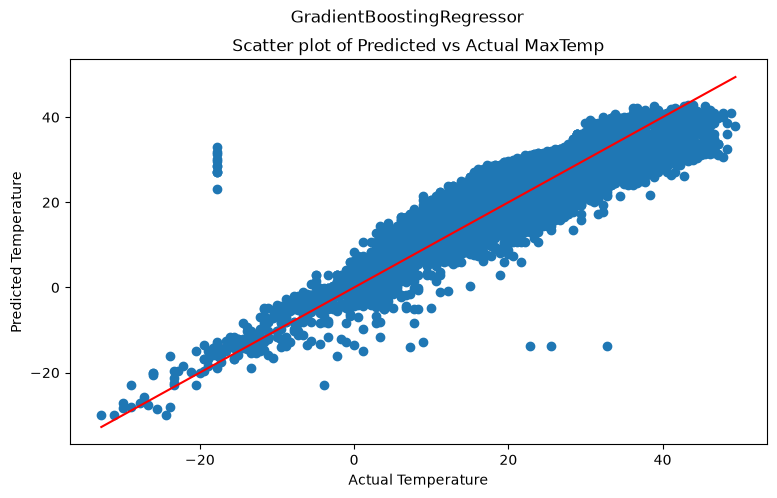

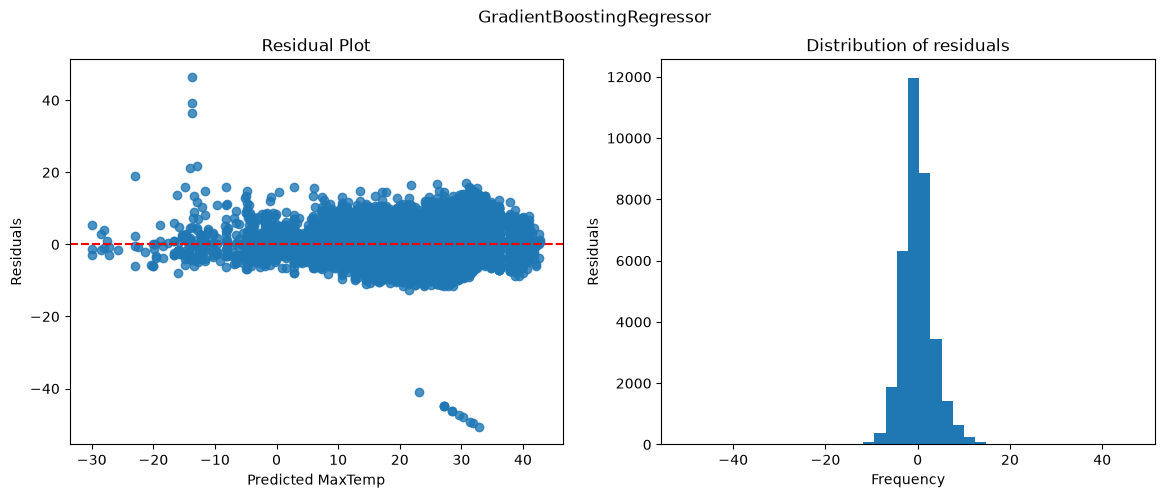

In [12]:
## Fit the Gradient Boosting model:
predicted_value = prediction_df['Predicted Values'][0]
# Predicted vs Actual MaxTemp:
plt.subplots(figsize=(9,5))
plt.scatter(y_test, predicted_value)
# Get perfect prediction line:
min_equal_value = min(predicted_value.min(), y_test.min())
max_equal_value = max(predicted_value.max(), y_test.max())
prefect_value = [min_equal_value, max_equal_value]
plt.plot(prefect_value, prefect_value, color="red")
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Scatter plot of Predicted vs Actual MaxTemp")
plt.suptitle("GradientBoostingRegressor")
plt.show()

# Residual plot:
error = y_test - predicted_value
fig, ax = plt.subplots(1, 2, figsize=(14,5))
sns.residplot(x=predicted_value, y=error, ax=ax[0])
ax[0].axhline(y=0, linestyle="--", color="red")
ax[0].set_xlabel("Predicted MaxTemp")
ax[0].set_ylabel("Residuals")
ax[0].set_title("Residual Plot")

ax[1].hist(error, bins=40)
ax[1].set_xlabel("Frequency")
ax[1].set_ylabel("Residuals")
ax[1].set_title("Distribution of residuals")
plt.suptitle("GradientBoostingRegressor")
plt.show()

## 7. What is the R² value and RMSE of the model? How these values indicate the model performance?

In [13]:
# write your answer here
# Root Mean Square Error 
print(f'Gradient Boosting Model RMSE: {round(prediction_df['RMSE'][0], 2)}')

# R2
print(f'Gradient Boosting Model R2: {round(prediction_df['R2'][0], 4)}')

Gradient Boosting Model RMSE: 3.46
Gradient Boosting Model R2: 0.8279


RMSE: The RMSE of Gradient Boosting model is 3.45 which indicates incorrect predictions are wrong by around 
3.45 Celsius degree.

R2: The R2 of Gradient Boosting model is 0.8305 which indicates the model explains 83.05% of the variation 
in maximum temperatures of the data set.

## 8. Discuss the model performance based on the plot

The Gradient Boosting model generally tracks actual maximum temperatures fairly well (R²=0.83), with central values ​​close to the 45° line. However, it often predicts lower high temperatures (>20°C), suggesting a lack of consideration for factors such as humidity or solar radiation. A few extreme outliers (e.g., -18°C predicted as 30°C) may reflect data errors rather than model weaknesses. The central error is close to zero (RMSE=3.45°C), confirming typical stable accuracy despite these individual errors.